# Risky Debt Model: Nested VFI Method

Canonical benchmark notebook for the corrected risky-debt model in `docs/environments/risky_debt.md`.
The environment and solver use the explicit risky rate `\tilde r(z, k', b')`, and the inner VFI loop clamps the Bellman update to `max(0, \cdot)` after maximizing over `(k', b')`.


In [1]:
import os
import sys
import time
from pathlib import Path

os.environ.setdefault("TF_CPP_MIN_LOG_LEVEL", "2")
os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib")
from pathlib import Path

_nb_file = globals().get("__vsc_ipynb_file__")
if _nb_file:
    _REPO_ROOT = Path(_nb_file).parent.parent
else:
    _REPO_ROOT = Path.cwd().parent
sys.path.insert(0, str(_REPO_ROOT))

import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf

from src.v2.evaluation import prepare_evaluation_run, save_figure, save_manifest_sections, save_solver_bundle
from src.v2.environments.risky_debt import EconomicParams, RiskyDebtEnv, ShockParams
from src.v2.solvers import NestedVFIConfig, NestedVFIGridConfig, solve_nested_vfi

print(f"TF version: {tf.__version__}")


TF version: 2.16.2


In [2]:
EXPERIMENT_NAME = "risky_debt_nested_vfi"

_nb_file = globals().get("__vsc_ipynb_file__")
if _nb_file:
    _repo_root = Path(_nb_file).parent.parent
else:
    _repo_root = Path.cwd().parent

RUN = prepare_evaluation_run(
    experiment_name=EXPERIMENT_NAME,
    save_run=True,
    results_root=str(_repo_root / "outputs" / "notebooks"),
    run_tag="part1-benchmark"
)
print(f"Run dir: {RUN['run_dir']}")

# Set to "FULL" for production results
PROFILE = "FULL"
_PROFILES = {
    "FAST_DEBUG": dict(
        EXO=20,
        ENDO_K=20,
        ENDO_B=20,
        MAX_INNER=500,
        MAX_OUTER=100,
        TOL_INNER=1e-6,
        TOL_OUTER_VALUE=1e-3,
    ),
    "FULL": dict(
        EXO=30,
        ENDO_K=50,
        ENDO_B=50,
        MAX_INNER=1000,
        MAX_OUTER=500,
        TOL_INNER=1e-6,
        TOL_OUTER_VALUE=1e-6,
    ),
}
P = _PROFILES[PROFILE]

env = RiskyDebtEnv(
    econ_params=EconomicParams(
        interest_rate=0.05,
        depreciation_rate=0.15,
        production_elasticity=0.7,
        cost_convex=0.01,
        tax=0.3,
        default_haircut=0.5,
        cost_inject_fixed=0.1,
        cost_inject_linear=0.05,
    ),
    shock_params=ShockParams(mu=0.0, rho=0.7, sigma=0.15),
    k_min_mult=0.05,
    k_max_mult=1.5,
    b_max_mult=4.0,
    b_min_mult=0.2,
)

config = NestedVFIConfig(
    grid=NestedVFIGridConfig(
        exo_sizes=[P["EXO"]],
        endo_sizes=[P["ENDO_K"], P["ENDO_B"]],
        exo_spacings=["log"],
        endo_spacings=["geometric", "linear"],
    ),
    max_iter_inner=P["MAX_INNER"],
    tol_inner=P["TOL_INNER"],
    max_iter_outer=P["MAX_OUTER"],
    tol_outer_value=P["TOL_OUTER_VALUE"],
)

save_manifest_sections(
    RUN,
    profile=PROFILE,
    solver="nested_vfi",
    solver_config={
        "exo_sizes": config.grid.exo_sizes,
        "endo_sizes": config.grid.endo_sizes,
        "exo_spacings": config.grid.exo_spacings,
        "endo_spacings": config.grid.endo_spacings,
        "max_iter_inner": config.max_iter_inner,
        "max_iter_outer": config.max_iter_outer,
        "tol_inner": config.tol_inner,
        "tol_outer_value": config.tol_outer_value,
    },
)

print(f"Profile: {PROFILE}")
print(f"State bounds: k in [{env.k_min:.2f}, {env.k_max:.2f}], b in [{env.b_min:.2f}, {env.b_max:.2f}], z in [{env.z_min:.3f}, {env.z_max:.3f}]")
print(f"Grid: z={P['EXO']} x k={P['ENDO_K']} x b={P['ENDO_B']}")
print(f"Grid spacing: z={config.grid.exo_spacings[0]}, k={config.grid.endo_spacings[0]}, b={config.grid.endo_spacings[1]}")


Run dir: /Users/wangzhaoxuan/Desktop/JPM-TSRL/DL_corp_finance/outputs/notebooks/risky_debt_nested_vfi/part1-benchmark
Profile: FULL
State bounds: k in [1.03, 30.87], b in [-24.70, 123.50], z in [0.533, 1.878]
Grid: z=30 x k=50 x b=50
Grid spacing: z=log, k=geometric, b=linear


In [3]:
t0 = time.perf_counter()
result = solve_nested_vfi(env, config=config)
wall_time = time.perf_counter() - t0

save_solver_bundle(
    RUN,
    result,
    summary={
        "solver": "nested_vfi",
        "backend": result["backend"],
        "dtype": result["dtype"],
        "device": result["device"],
        "stop_reason": result["stop_reason"],
        "converged_outer": result["converged_outer"],
        "n_outer": result["n_outer"],
        "n_inner_last": result["n_inner_last"],
        "wall_time_sec": wall_time,
    },
    name="nested_vfi",
)

grids = result["grids"]
z_grid = np.asarray(grids["exo_grids_1d"][0])
k_grid = np.asarray(grids["endo_grids_1d"][0])
b_grid = np.asarray(grids["endo_grids_1d"][1])
n_z, n_k, n_b = len(z_grid), len(k_grid), len(b_grid)

value_3d = np.asarray(result["value"]).reshape(n_z, n_k, n_b)
policy_endo_4d = np.asarray(result["policy_endo"]).reshape(n_z, n_k, n_b, env.action_dim())
default_mask = np.asarray(result["default_mask"])
r_tilde_grid = np.asarray(result["r_tilde_grid"])
residual = np.asarray(result["zero_profit_residual"])
funded_mask = np.asarray(result["funded_mask"])
solvent_mask = ~default_mask
policy_b_solvent = policy_endo_4d[..., 1][solvent_mask]
min_policy_b_solvent = np.min(policy_b_solvent) if policy_b_solvent.size else np.nan
bmin_bind_share_solvent = np.mean(np.isclose(policy_b_solvent, env.b_min, atol=1e-10, rtol=0.0)) if policy_b_solvent.size else np.nan

outer_value_diff_final = result["outer_value_diff_history"][-1] if result["outer_value_diff_history"] else np.nan
pricing_diff_final = result["pricing_diff_history"][-1] if result["pricing_diff_history"] else np.nan
max_residual = np.nanmax(np.abs(residual[funded_mask])) if funded_mask.any() else np.nan

print(f"Backend: {result['backend']} | dtype={result['dtype']} | device={result['device']}")
print(f"Stop reason: {result['stop_reason']} | wall={wall_time:.2f}s")
print(f"Outer iterations: {result['n_outer']} | inner last: {result['n_inner_last']}")
print(f"Final outer value diff: {outer_value_diff_final:.2f}")
print(f"Final pricing diff: {pricing_diff_final:.2f}")
print(f"Value range: [{value_3d.min():.3f}, {value_3d.max():.3f}]")
print(f"Default fraction: {default_mask.mean():.2%}")
print(f"Infinite-rate fraction: {np.isinf(r_tilde_grid).mean():.2%}")
print(f"Max |zero-profit residual| on funded cells: {max_residual:.3e}")
print(f"Min chosen b' on solvent states: {min_policy_b_solvent:.3f}")
print(f"Share of solvent states at b_min: {bmin_bind_share_solvent:.2%}")


Nested VFI outer=  0 | inner=converged (22 iters, diff=4.37e-07) | outer_value_diff=3.82 | pricing_diff=0.95
Nested VFI outer=  1 | inner=converged (22 iters, diff=8.53e-07) | outer_value_diff=3.79 | pricing_diff=0.95
Nested VFI outer=  2 | inner=converged (25 iters, diff=8.09e-07) | outer_value_diff=3.71 | pricing_diff=0.95
Nested VFI outer=  3 | inner=converged (27 iters, diff=7.53e-07) | outer_value_diff=3.51 | pricing_diff=0.95
Nested VFI outer=  4 | inner=converged (30 iters, diff=5.74e-07) | outer_value_diff=3.41 | pricing_diff=0.95
Nested VFI outer=  5 | inner=converged (33 iters, diff=9.91e-07) | outer_value_diff=3.35 | pricing_diff=0.95
Nested VFI outer=  6 | inner=converged (34 iters, diff=9.22e-07) | outer_value_diff=3.24 | pricing_diff=0.95
Nested VFI outer=  7 | inner=converged (41 iters, diff=7.75e-07) | outer_value_diff=3.17 | pricing_diff=0.95
Nested VFI outer=  8 | inner=converged (42 iters, diff=8.11e-07) | outer_value_diff=3.02 | pricing_diff=0.95
Nested VFI outer=  

In [4]:
VALUE_TOL = 1e-8

def _pick_k_idx_for_b_slice(value_at_z):
    solvent = value_at_z > VALUE_TOL
    solvent_count = solvent.sum(axis=1)
    default_count = (~solvent).sum(axis=1)
    mixed = (solvent_count > 0) & (default_count > 0)
    if mixed.any():
        score = np.minimum(solvent_count, default_count)
        return int(np.argmax(np.where(mixed, score, -1)))
    if (solvent_count > 0).any():
        return int(np.argmax(solvent_count))
    return value_at_z.shape[0] // 2

def _pick_b_idx_for_solvent_slice(value_at_k):
    solvent_idx = np.flatnonzero(value_at_k > VALUE_TOL)
    if solvent_idx.size:
        return int(solvent_idx[solvent_idx.size // 2])
    return len(value_at_k) // 2

def _mask_policy(policy_slice, value_slice):
    return np.where(value_slice[:, None] > VALUE_TOL, policy_slice, np.nan)

def _boundary_location(x, value_slice):
    solvent = value_slice > VALUE_TOL
    changes = np.flatnonzero(solvent[1:] != solvent[:-1])
    if changes.size == 0:
        return None
    i = int(changes[0])
    return 0.5 * (float(x[i]) + float(x[i + 1]))

def _critical_z_boundary(value_grid, z_nodes):
    boundary = np.full(value_grid.shape[1:], np.nan, dtype=float)
    for k_idx in range(value_grid.shape[1]):
        for b_idx in range(value_grid.shape[2]):
            solvent_idx = np.flatnonzero(value_grid[:, k_idx, b_idx] > VALUE_TOL)
            if solvent_idx.size == 0:
                continue
            first_solvent = int(solvent_idx[0])
            if first_solvent == 0:
                boundary[k_idx, b_idx] = float(z_nodes[0])
            else:
                boundary[k_idx, b_idx] = 0.5 * (
                    float(z_nodes[first_solvent - 1]) + float(z_nodes[first_solvent])
                )
    return boundary

def _pick_b_idx_near_frontier(critical_z_row, z_target, z_nodes):
    interior = np.flatnonzero(
        np.isfinite(critical_z_row)
        & (critical_z_row > float(z_nodes[0]))
        & (critical_z_row < float(z_nodes[-1]))
    )
    if interior.size:
        return int(interior[np.argmin(np.abs(critical_z_row[interior] - z_target))])
    finite = np.flatnonzero(np.isfinite(critical_z_row))
    if finite.size:
        return int(finite[np.argmin(np.abs(critical_z_row[finite] - z_target))])
    return len(critical_z_row) // 2

z_bar = float(np.exp(env.shocks.mu))
z_ref_idx = int(np.argmin(np.abs(z_grid - z_bar)))
k_ref_idx = _pick_k_idx_for_b_slice(value_3d[z_ref_idx])
b_ref_idx = _pick_b_idx_for_solvent_slice(value_3d[z_ref_idx, k_ref_idx])
z_ref = float(z_grid[z_ref_idx])
k_ref = float(k_grid[k_ref_idx])
b_ref = float(b_grid[b_ref_idx])
debt_discount_grid = np.where(np.isfinite(r_tilde_grid), 1.0 / (1.0 + r_tilde_grid), 0.0)
critical_z_grid = _critical_z_boundary(value_3d, z_grid)
k_diag_idx = k_ref_idx
b_diag_idx = _pick_b_idx_near_frontier(critical_z_grid[k_diag_idx], z_ref, z_grid)
k_diag = float(k_grid[k_diag_idx])
b_diag = float(b_grid[b_diag_idx])
discount_cap = 1.0 / (1.0 + env.econ.interest_rate)

z_slice = z_grid
k_slice = k_grid
b_slice = b_grid

policy_z = policy_endo_4d[:, k_ref_idx, b_ref_idx, :]
policy_k = policy_endo_4d[z_ref_idx, :, b_ref_idx, :]
policy_b = policy_endo_4d[z_ref_idx, k_ref_idx, :, :]
critical_z_b = critical_z_grid[k_diag_idx, :]
critical_z_k = critical_z_grid[:, b_diag_idx]
discount_z = debt_discount_grid[:, k_diag_idx, b_diag_idx]
discount_k = debt_discount_grid[z_ref_idx, :, b_diag_idx]
discount_b = debt_discount_grid[z_ref_idx, k_diag_idx, :]
value_z = value_3d[:, k_ref_idx, b_ref_idx]
value_k = value_3d[z_ref_idx, :, b_ref_idx]
value_b = value_3d[z_ref_idx, k_ref_idx, :]

policy_z_plot = _mask_policy(policy_z, value_z)
policy_k_plot = _mask_policy(policy_k, value_k)
policy_b_plot = _mask_policy(policy_b, value_b)

z_boundary = _boundary_location(z_slice, value_z)
k_boundary = _boundary_location(k_slice, value_k)
b_boundary = _boundary_location(b_slice, value_b)


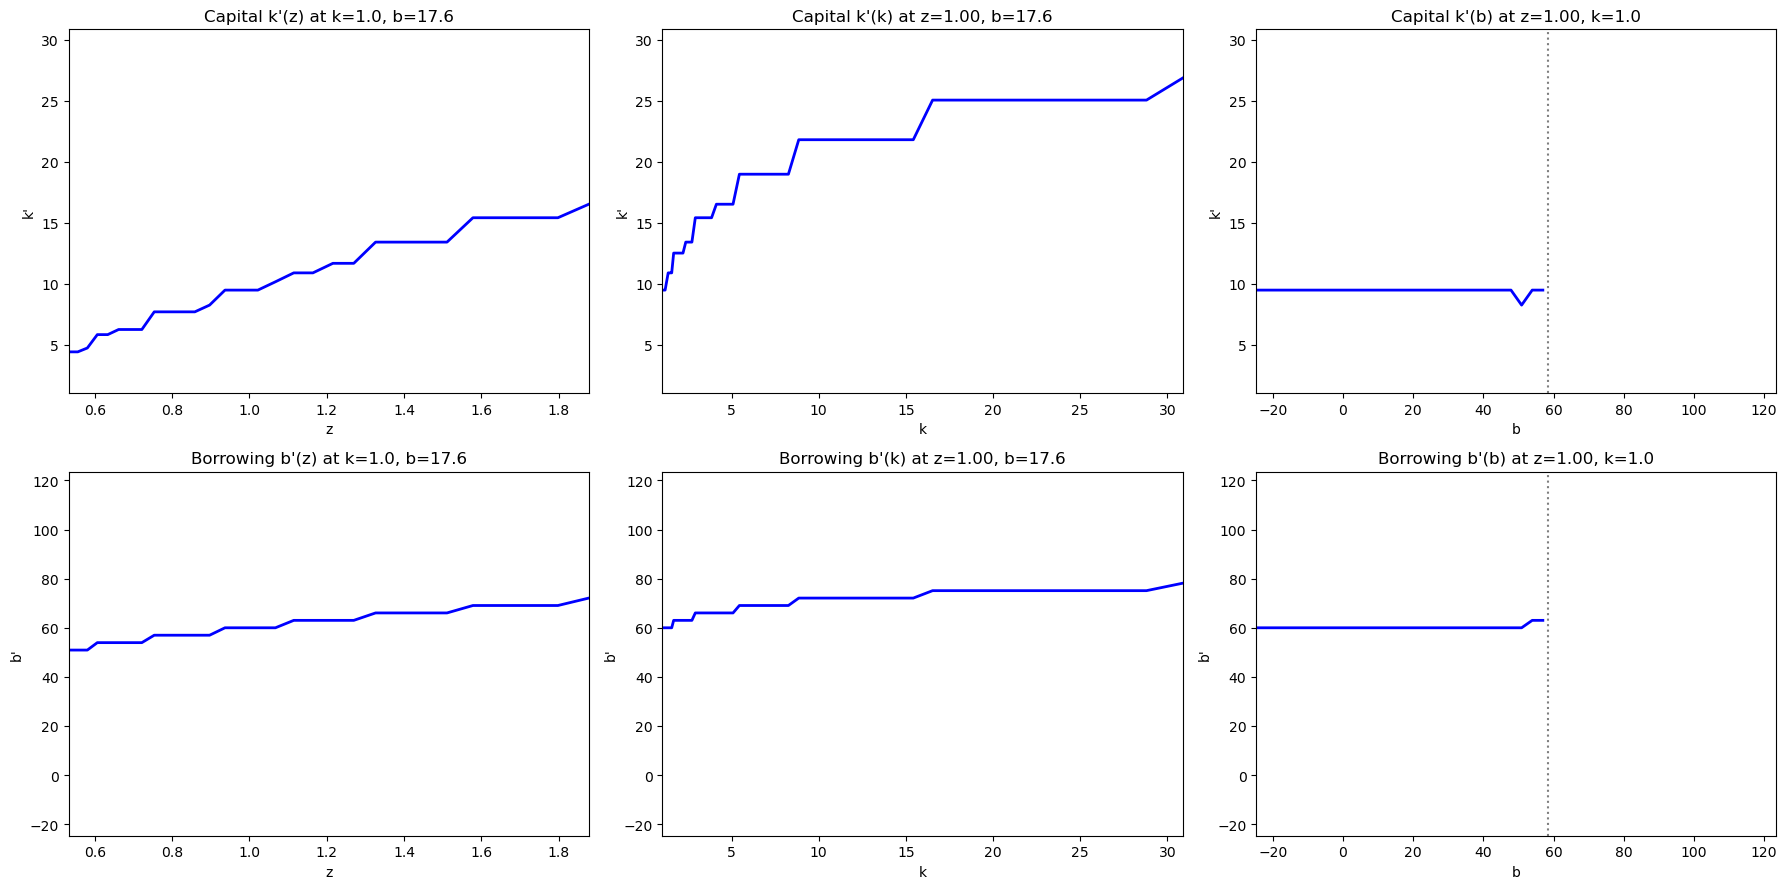

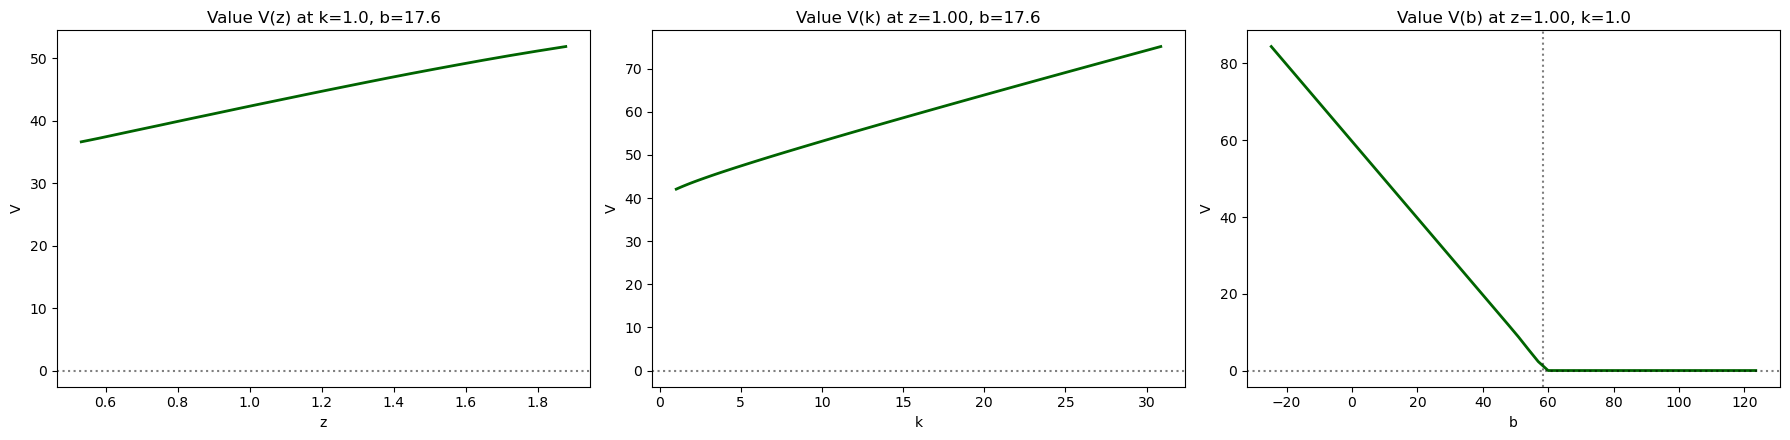

In [5]:
policy_line = dict(color="blue", linewidth=2.0)
value_line = dict(color="darkgreen", linewidth=2.0)

fig, axes = plt.subplots(2, 3, figsize=(18, 9))

x_limits = [
    (float(z_grid[0]), float(z_grid[-1])),
    (float(k_grid[0]), float(k_grid[-1])),
    (float(b_grid[0]), float(b_grid[-1])),
]
kprime_limits = (float(k_grid[0]), float(k_grid[-1]))
bprime_limits = (float(b_grid[0]), float(b_grid[-1]))

axes[0, 0].plot(z_slice, policy_z_plot[:, 0], **policy_line)
axes[0, 0].set_title(f"Capital k'(z) at k={k_ref:.1f}, b={b_ref:.1f}")
axes[0, 0].set_xlabel("z")
axes[0, 0].set_ylabel("k'")
axes[0, 0].set_xlim(*x_limits[0])
axes[0, 0].set_ylim(*kprime_limits)
if z_boundary is not None:
    axes[0, 0].axvline(z_boundary, color="black", linestyle=":", alpha=0.5)

axes[0, 1].plot(k_slice, policy_k_plot[:, 0], **policy_line)
axes[0, 1].set_title(f"Capital k'(k) at z={z_bar:.2f}, b={b_ref:.1f}")
axes[0, 1].set_xlabel("k")
axes[0, 1].set_ylabel("k'")
axes[0, 1].set_xlim(*x_limits[1])
axes[0, 1].set_ylim(*kprime_limits)
if k_boundary is not None:
    axes[0, 1].axvline(k_boundary, color="black", linestyle=":", alpha=0.5)

axes[0, 2].plot(b_slice, policy_b_plot[:, 0], **policy_line)
axes[0, 2].set_title(f"Capital k'(b) at z={z_bar:.2f}, k={k_ref:.1f}")
axes[0, 2].set_xlabel("b")
axes[0, 2].set_ylabel("k'")
axes[0, 2].set_xlim(*x_limits[2])
axes[0, 2].set_ylim(*kprime_limits)
if b_boundary is not None:
    axes[0, 2].axvline(b_boundary, color="black", linestyle=":", alpha=0.5)

axes[1, 0].plot(z_slice, policy_z_plot[:, 1], **policy_line)
axes[1, 0].set_title(f"Borrowing b'(z) at k={k_ref:.1f}, b={b_ref:.1f}")
axes[1, 0].set_xlabel("z")
axes[1, 0].set_ylabel("b'")
axes[1, 0].set_xlim(*x_limits[0])
axes[1, 0].set_ylim(*bprime_limits)
if z_boundary is not None:
    axes[1, 0].axvline(z_boundary, color="black", linestyle=":", alpha=0.5)

axes[1, 1].plot(k_slice, policy_k_plot[:, 1], **policy_line)
axes[1, 1].set_title(f"Borrowing b'(k) at z={z_bar:.2f}, b={b_ref:.1f}")
axes[1, 1].set_xlabel("k")
axes[1, 1].set_ylabel("b'")
axes[1, 1].set_xlim(*x_limits[1])
axes[1, 1].set_ylim(*bprime_limits)
if k_boundary is not None:
    axes[1, 1].axvline(k_boundary, color="black", linestyle=":", alpha=0.5)

axes[1, 2].plot(b_slice, policy_b_plot[:, 1], **policy_line)
axes[1, 2].set_title(f"Borrowing b'(b) at z={z_bar:.2f}, k={k_ref:.1f}")
axes[1, 2].set_xlabel("b")
axes[1, 2].set_ylabel("b'")
axes[1, 2].set_xlim(*x_limits[2])
axes[1, 2].set_ylim(*bprime_limits)
if b_boundary is not None:
    axes[1, 2].axvline(b_boundary, color="black", linestyle=":", alpha=0.5)

plt.tight_layout()
save_figure(RUN, fig, "policy_slices")
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(18, 4.5))
for ax, x, y, title, xlabel in [
    (axes[0], z_slice, value_z, f"Value V(z) at k={k_ref:.1f}, b={b_ref:.1f}", "z"),
    (axes[1], k_slice, value_k, f"Value V(k) at z={z_bar:.2f}, b={b_ref:.1f}", "k"),
    (axes[2], b_slice, value_b, f"Value V(b) at z={z_bar:.2f}, k={k_ref:.1f}", "b"),
]:
    ax.plot(x, y, **value_line)
    ax.axhline(0.0, color="black", linestyle=":", alpha=0.5)
    boundary = _boundary_location(x, y)
    if boundary is not None:
        ax.axvline(boundary, color="black", linestyle=":", alpha=0.5)
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel("V")

plt.tight_layout()
save_figure(RUN, fig, "value_slices")
plt.show()


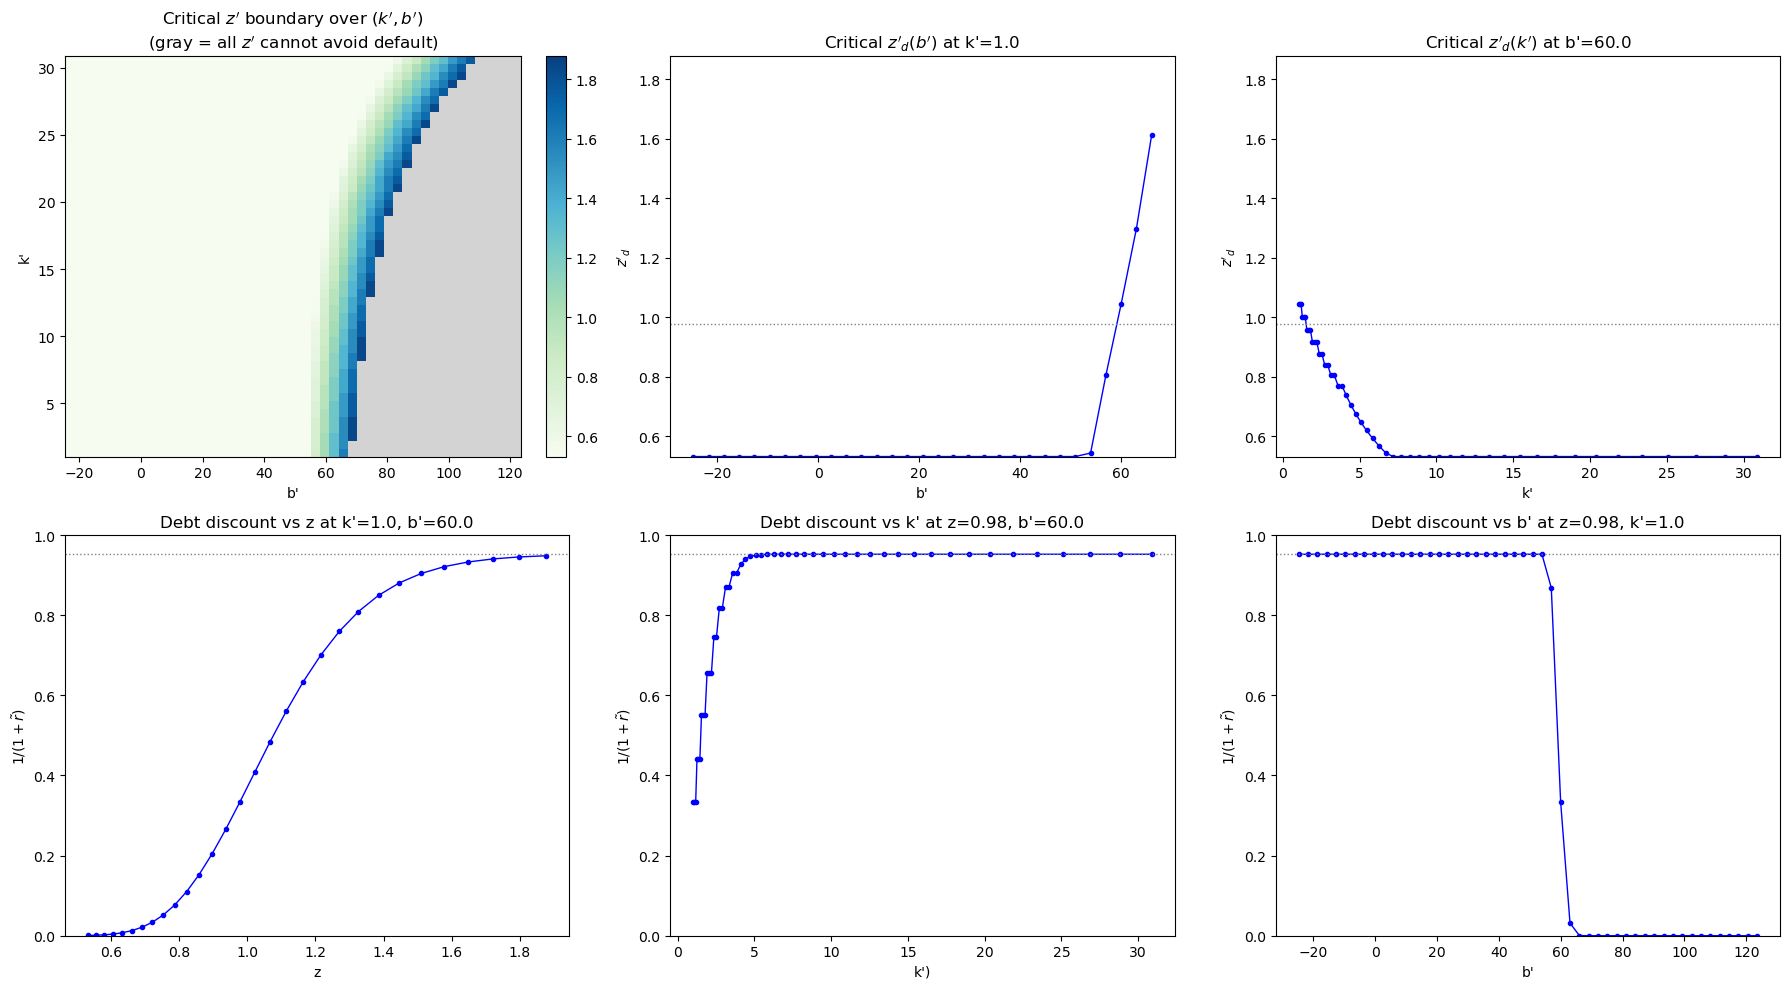

In [6]:
line_style = dict(color="blue", linewidth=1.0)

z_idx = z_ref_idx
critical_cmap = plt.cm.GnBu.copy()
critical_cmap.set_bad(color="lightgray")

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

im = axes[0, 0].imshow(
    critical_z_grid,
    origin="lower",
    aspect="auto",
    extent=[b_grid[0], b_grid[-1], k_grid[0], k_grid[-1]],
    cmap=critical_cmap,
    vmin=float(z_grid[0]),
    vmax=float(z_grid[-1]),
)
axes[0, 0].set_title("Critical $z'$ boundary over $(k', b')$\n(gray = all $z'$ cannot avoid default)")
axes[0, 0].set_xlabel("b'")
axes[0, 0].set_ylabel("k'")
fig.colorbar(im, ax=axes[0, 0], fraction=0.046)

axes[0, 1].plot(b_slice, critical_z_b, marker=".", **line_style)
axes[0, 1].axhline(z_ref, color="gray", linestyle=":", linewidth=1.0)
axes[0, 1].set_title(f"Critical $z'_d(b')$ at k'={k_diag:.1f}")
axes[0, 1].set_xlabel("b'")
axes[0, 1].set_ylabel("$z'_d$")
axes[0, 1].set_ylim(float(z_grid[0]), float(z_grid[-1]))

axes[0, 2].plot(k_slice, critical_z_k, marker=".", **line_style)
axes[0, 2].axhline(z_ref, color="gray", linestyle=":", linewidth=1.0)
axes[0, 2].set_title(f"Critical $z'_d(k')$ at b'={b_diag:.1f}")
axes[0, 2].set_xlabel("k'")
axes[0, 2].set_ylabel("$z'_d$")
axes[0, 2].set_ylim(float(z_grid[0]), float(z_grid[-1]))

axes[1, 0].plot(z_slice, discount_z, marker=".", **line_style)
axes[1, 0].axhline(discount_cap, color="gray", linestyle=":", linewidth=1.0)
axes[1, 0].set_title(f"Debt discount vs z at k'={k_diag:.1f}, b'={b_diag:.1f}")
axes[1, 0].set_xlabel("z")
axes[1, 0].set_ylabel("$1 / (1 + \\tilde r)$")
axes[1, 0].set_ylim(0.0, 1.0)

axes[1, 1].plot(k_slice, discount_k, marker=".", **line_style)
axes[1, 1].axhline(discount_cap, color="gray", linestyle=":", linewidth=1.0)
axes[1, 1].set_title(f"Debt discount vs k' at z={z_ref:.2f}, b'={b_diag:.1f}")
axes[1, 1].set_xlabel("k')")
axes[1, 1].set_ylabel("$1 / (1 + \\tilde r)$")
axes[1, 1].set_ylim(0.0, 1.0)

axes[1, 2].plot(b_slice, discount_b, marker=".", **line_style)
axes[1, 2].axhline(discount_cap, color="gray", linestyle=":", linewidth=1.0)
axes[1, 2].set_title(f"Debt discount vs b' at z={z_ref:.2f}, k'={k_diag:.1f}")
axes[1, 2].set_xlabel("b'")
axes[1, 2].set_ylabel("$1 / (1 + \\tilde r)$")
axes[1, 2].set_ylim(0.0, 1.0)

plt.tight_layout()
save_figure(RUN, fig, "boundary_and_discount_slices")
plt.show()
